# Modelo de regresión logística con WOE para la Estimación de la probabilidad de Incumplimiento

In [3]:
# Instalamos las paqueterías necesarias
!pip install statsmodels
!pip install scorecardpy

In [ ]:
import sys
import os
from pathlib import Path
from scorecardpy import woebin, woebin_ply
import pandas as pd
import scorecardpy as sc
import warnings
warnings.filterwarnings('ignore')

# ── Anchor ────────────────────────────────────────────────────────────────
# Este notebook vive en notebooks/P1_LogReg/
_NB_DIR    = Path(os.path.abspath('')).resolve()   # notebooks/P1_LogReg/
_REPO_ROOT = _NB_DIR.parent.parent                 # repo root

_DATA_DIR  = _REPO_ROOT / 'data' / 'splits'
_BIVAR_DIR = _REPO_ROOT / 'data' / 'variables_bivariadas'
_REPORTS   = _REPO_ROOT / 'reports'

os.makedirs(str(_BIVAR_DIR), exist_ok=True)
os.makedirs(str(_REPORTS), exist_ok=True)

if str(_REPO_ROOT / 'src' / 'utils') not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT / 'src' / 'utils'))

from evaluation import (
    evaluate_binary_model,
    threshold_by_ks,
    population_stability_index,
    psi_interpretation,
)

print("--- Iniciando con Carga de Datos ---")

X_train = pd.read_csv(_DATA_DIR / 'X_train.csv')
y_train = pd.read_csv(_DATA_DIR / 'y_train.csv')
X_test  = pd.read_csv(_DATA_DIR / 'X_test.csv')
y_test  = pd.read_csv(_DATA_DIR / 'y_test.csv')
X_oos   = pd.read_csv(_DATA_DIR / 'X_oos.csv')
y_oos   = pd.read_csv(_DATA_DIR / 'y_oos.csv')

# Cargar variables aprobadas por IV (33 candidatas)
candidatas_df = pd.read_csv(_BIVAR_DIR / 'bivariado_variables_candidatas.csv')
variables_candidatas = candidatas_df['variable'].tolist()

print(f"Dimensiones Originales -> Train: {X_train.shape} | Test: {X_test.shape} | OOT: {X_oos.shape}")
print(f"Filtrando a solo {len(variables_candidatas)} variables candidatas del análisis bivariado...")

# Preparamos datasets con el target para scorecardpy
train = X_train[variables_candidatas].copy()
train['target'] = y_train['target'].values
test = X_test[variables_candidatas].copy()
test['target'] = y_test['target'].values
oot = X_oos[variables_candidatas].copy()
oot['target'] = y_oos['target'].values

print("Calculando bins y WOE exclusivamente en conjunto de Train...")
bins = sc.woebin(train, y='target', min_iv=0.10, positive='1', print_step=0)

train_woe = sc.woebin_ply(train, bins, print_step=0)
test_woe  = sc.woebin_ply(test,  bins, print_step=0)
oot_woe   = sc.woebin_ply(oot,   bins, print_step=0)

X_train_woe = train_woe.drop('target', axis=1)
y_train_tgt = train_woe['target']
X_test_woe  = test_woe.drop('target', axis=1)
y_test_tgt  = test_woe['target']
X_oot_woe   = oot_woe.drop('target', axis=1)
y_oot_tgt   = oot_woe['target']


# Selección por VIF y Stepwise

--- 1. Selección por VIF (Umbral < 5) ---
Variables eliminadas por VIF: 16
Sobrevivientes VIF: 17

--- 2. Selección Stepwise Bidireccional (p-value < 0.05) ---
Variables definitivas tras Stepwise: 11
Lista final: ['x85_woe', 'x120_woe', 'x20_woe', 'x99_woe', 'x12_woe', 'x14_woe', 'x57_woe', 'x104_woe', 'x11_woe', 'x35_woe', 'x81_woe']

--- 3. Entrenamiento Regresión Logística ---

Desempeño final de la LR de Bruno vs tu RF usando evaluation.py:
          auc      ks  recall  precision  threshold
Train  0.7997  0.4820  0.7834     0.1856     0.4583
Test   0.7243  0.3565  0.6478     0.1580     0.4583
OOS    0.7370  0.3834  0.6456     0.1579     0.4583

--- 4. Cálculo de PSI y Scorecard ---


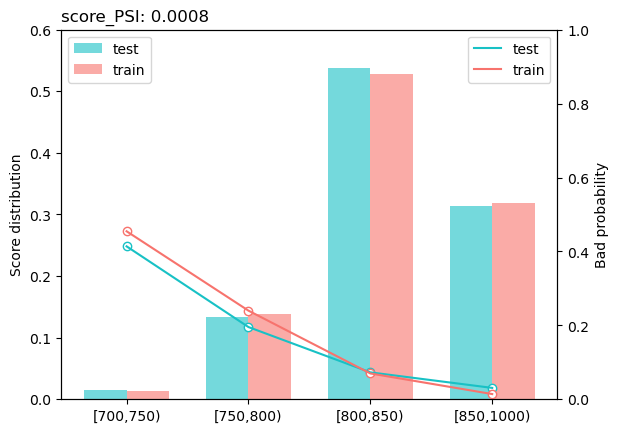

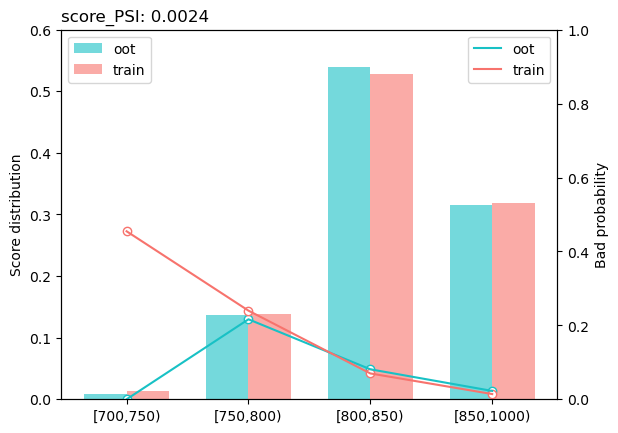

PSI Test: 0.0008 | PSI OOS: 0.0024


In [ ]:
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("--- 1. Selección por VIF (Umbral < 5) ---")
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

X_train_vif = X_train_woe.copy()
max_vif = 10
eliminadas_vif = []

while max_vif >= 5:
    vif_df = calculate_vif(X_train_vif)
    max_vif = vif_df['VIF'].max()
    if max_vif >= 5:
        var_to_drop = vif_df.sort_values('VIF', ascending=False).iloc[0]['Variable']
        X_train_vif = X_train_vif.drop(columns=[var_to_drop])
        eliminadas_vif.append(var_to_drop)

print(f"Variables eliminadas por VIF: {len(eliminadas_vif)}")
print(f"Sobrevivientes VIF: {len(X_train_vif.columns)}")

print("\n--- 2. Selección Stepwise Bidireccional (p-value < 0.05) ---")
def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.05):
    included = []
    features = X.columns.tolist()
    while True:
        changed = False
        excluded = list(set(features) - set(included))
        new_pvalues = pd.Series(index=excluded, dtype=float)
        
        for new_var in excluded:
            try:
                model = sm.Logit(y, sm.add_constant(X[included + [new_var]])).fit(disp=0)
                new_pvalues[new_var] = model.pvalues[new_var]
            except:
                new_pvalues[new_var] = 1.0
                
        if not new_pvalues.empty:
            best_pval = new_pvalues.min()
            if best_pval < threshold_in:
                best_var = new_pvalues.idxmin()
                included.append(best_var)
                changed = True
                
        if included:
            try:
                model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
                pvalues = model.pvalues.drop('const')
                worst_pval = pvalues.max()
                if worst_pval > threshold_out:
                    worst_var = pvalues.idxmax()
                    included.remove(worst_var)
                    changed = True
            except:
                pass
                
        if not changed:
            break
    return included

features_finales = stepwise_selection(X_train_vif, y_train_tgt)
print(f"Variables definitivas tras Stepwise: {len(features_finales)}")
print(f"Lista final: {features_finales}")

# Filtrar a solo las variables finales
X_train_final = X_train_vif[features_finales]
X_test_final  = X_test_woe[features_finales]
X_oot_final   = X_oot_woe[features_finales]

print("\n--- 3. Entrenamiento Regresión Logística ---")
clf = LogisticRegression(penalty=None, solver='lbfgs', class_weight='balanced', random_state=42)
clf.fit(X_train_final, y_train_tgt)

y_proba_train = clf.predict_proba(X_train_final)[:, 1]
y_proba_test  = clf.predict_proba(X_test_final)[:, 1]
y_proba_oot   = clf.predict_proba(X_oot_final)[:, 1]

# Evaluando métricas usando la lógica de src.evaluation
opt_thresh = threshold_by_ks(y_train_tgt, y_proba_train)

train_eval = evaluate_binary_model(y_train_tgt, y_proba_train, opt_thresh)
test_eval  = evaluate_binary_model(y_test_tgt,  y_proba_test,  opt_thresh)
oot_eval   = evaluate_binary_model(y_oot_tgt,   y_proba_oot,   opt_thresh)

df_metrics = pd.DataFrame([train_eval, test_eval, oot_eval], index=["Train", "Test", "OOS"])
print("\nDesempeño final de la LR usando evaluation.py:")
print(df_metrics[['auc', 'ks', 'recall', 'precision', 'threshold']].round(4))

print("\n--- 4. Cálculo de PSI (evaluation.py) ---")
psi_test = population_stability_index(y_proba_train, y_proba_test, n_bins=10)
psi_oos  = population_stability_index(y_proba_train, y_proba_oot,  n_bins=10)

print(f"PSI Test: {psi_test:.4f} | PSI OOS: {psi_oos:.4f}")
print(f"Interpretación Test: {psi_interpretation(psi_test)}")
print(f"Interpretación OOS:  {psi_interpretation(psi_oos)}")


## Comparación:

| Modelo                  | AUC OOS | KS OOS | Recall OOS | Gap train-OOS | PSI OOS |
| ----------------------- | ------: | -----: | ---------: | ------------: | ------: |
| Random Forest           |   0.757 |  0.429 |      0.646 |         0.176 |   0.052 |
| Regresión Logística WOE |   0.737 |  0.383 |      0.646 |         0.063 |   0.002 |


- RF gana en discriminación: mejor AUC y KS.
- RL gana en estabilidad: gap mucho menor y PSI bajísimo.
- Recall está prácticamente igual.
- RL es más defendible regulatoriamente por interpretabilidad. 